# Fáze 6: KNN podobnost


In [1]:
import os, sys
from pathlib import Path
_PROJECT_ROOT = Path(os.path.abspath("")).parent if Path(os.path.abspath("")).name == "notebooks" else Path(os.path.abspath(""))
os.chdir(_PROJECT_ROOT)
sys.path.insert(0, str(_PROJECT_ROOT))

import pandas as pd
import numpy as np
from IPython.display import Image, display

## 1. Cross-validace: výběr K

,k,mean_f1_macro,std_f1_macro,mean_accuracy,std_accuracy
0,3,0.918694,0.007510,0.934406,0.004869
1,5,0.921640,0.008489,0.937061,0.005927
2,7,0.919934,0.007805,0.935696,0.005575
3,10,0.917468,0.005819,0.933837,0.004476


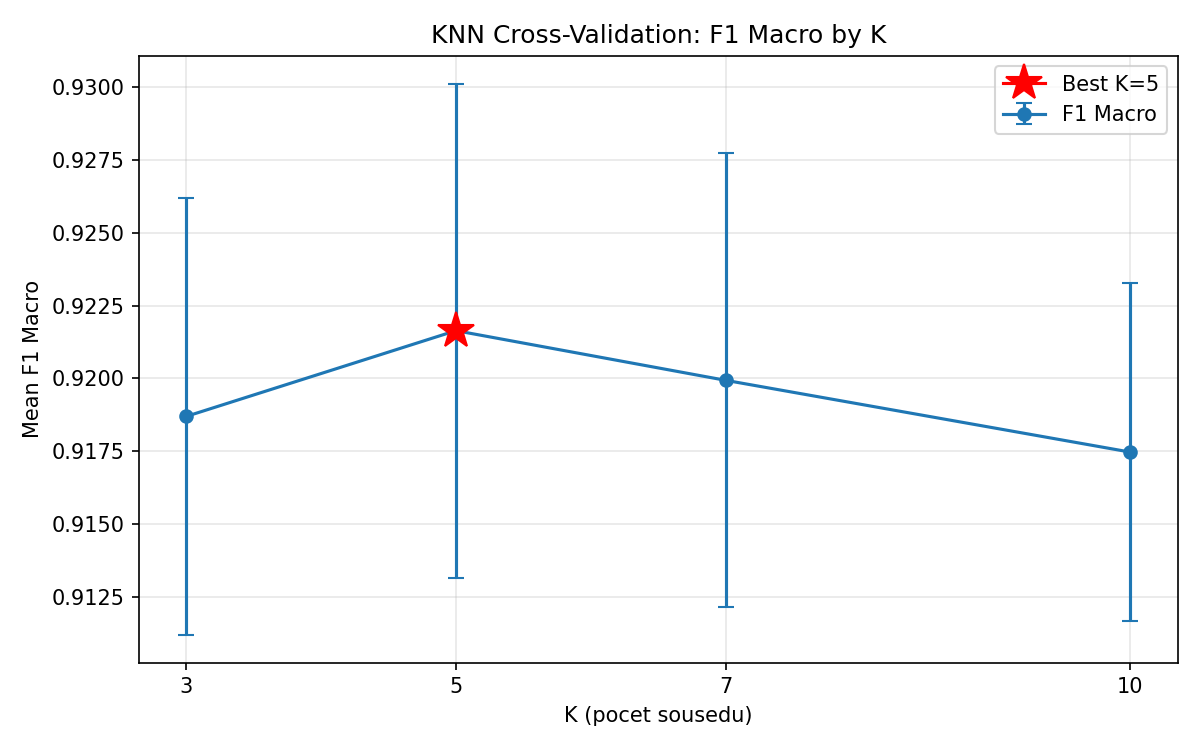

In [2]:
cv = pd.read_csv("results/phase6_knn/knn_cv_results.csv")
display(cv)
display(Image(filename="results/phase6_knn/knn_cv_f1_by_k.png"))

## 2. Shoda KNN vs. XGBoost

,class,agreement,knn_accuracy,xgb_accuracy
0,shelf_picking,0.959511,0.938695,0.986495
1,front_zone_bin,0.955032,0.938695,0.986495
2,special_zone,0.951493,0.938695,0.986495
3,floor_block,0.858491,0.938695,0.986495
4,pallet_rack,0.888446,0.938695,0.986495
5,overall,0.943399,0.938695,0.986495


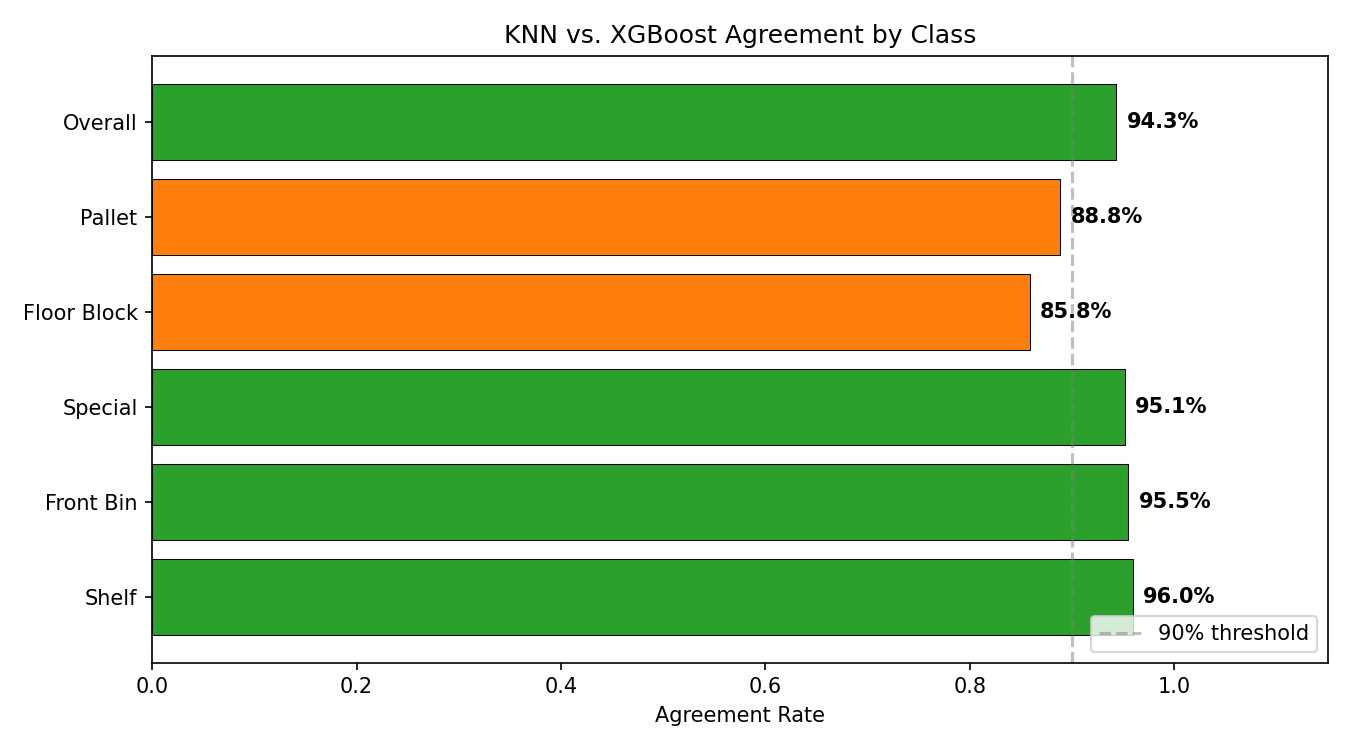

In [3]:
ag = pd.read_csv("results/phase6_knn/knn_agreement_summary.csv")
display(ag)
display(Image(filename="results/phase6_knn/knn_agreement_by_class.png"))

## 3. Porovnání přesnosti KNN vs. XGBoost per třída

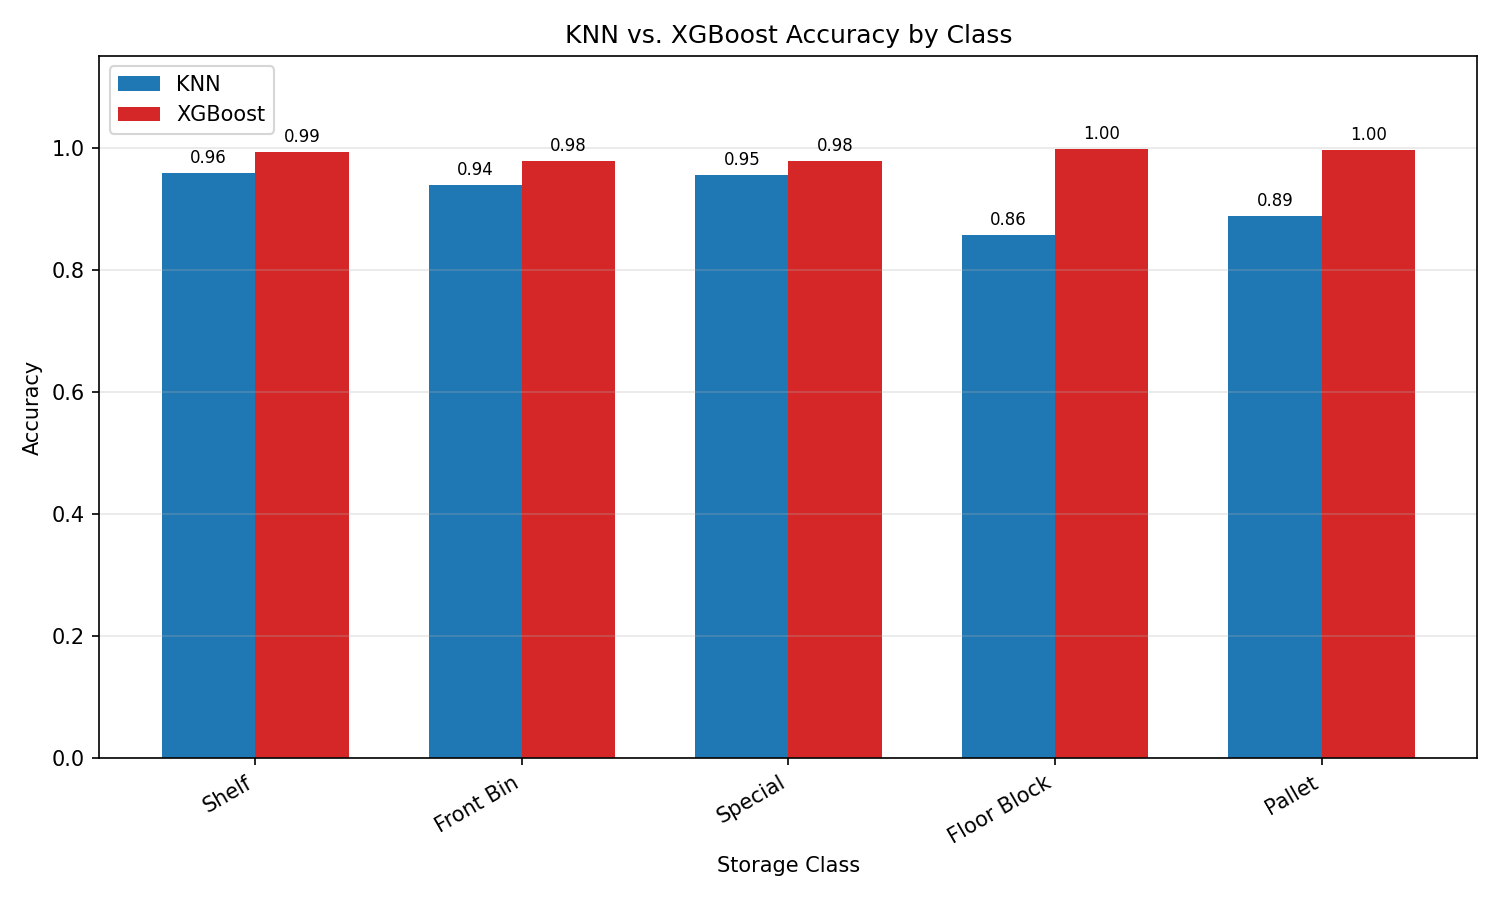

In [4]:
display(Image(filename="results/phase6_knn/knn_vs_xgb_accuracy.png"))

## 4. Heatmapa neshod XGBoost vs. KNN

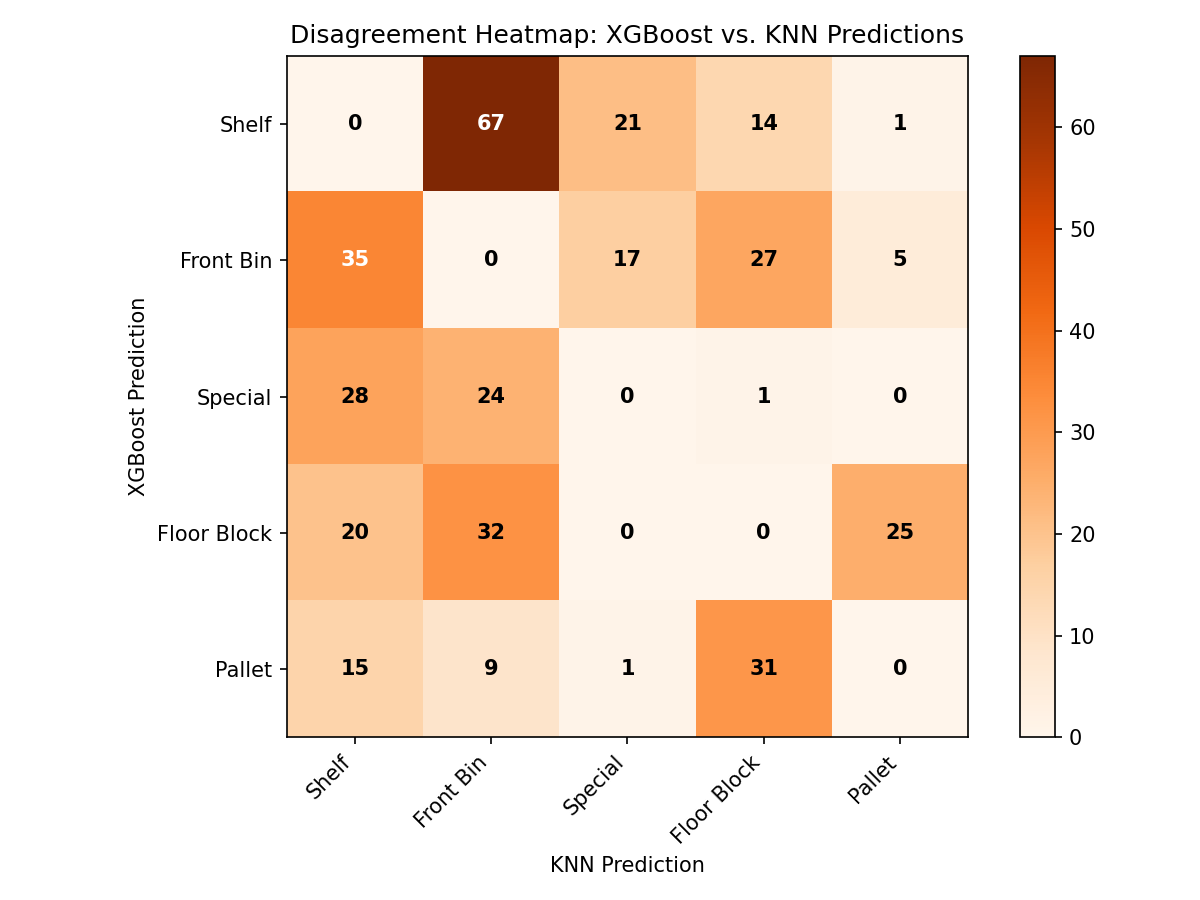

In [5]:
display(Image(filename="results/phase6_knn/disagreement_heatmap.png"))

## 5. Sanity check: příklady s KNN sousedy

In [6]:
sc = pd.read_csv("results/phase6_knn/sanity_check_examples.csv")
display(sc)

,product_id,true_class,xgb_pred,knn_vote,agree,neighbor_1_id,neighbor_1_class,neighbor_1_dist,neighbor_2_id,neighbor_2_class,neighbor_2_dist,neighbor_3_id,neighbor_3_class,neighbor_3_dist,neighbor_4_id,neighbor_4_class,neighbor_4_dist,neighbor_5_id,neighbor_5_class,neighbor_5_dist
0,8627c1a400bf12820b1fefd750005aea,shelf_picking,shelf_picking,shelf_picking,True,0285a1295a18a4d37c11fa446d4c1345,shelf_picking,0.000776,65665f545332ae2d0532d676f841163c,shelf_picking,0.004331,65ffac7c6e6c38822b7fa3f801511114,shelf_picking,0.004386,c9316b04fcac70510dfc554e184e35f8,shelf_picking,0.004386,8596caf32035799ab3365b1f27f1cedb,shelf_picking,0.004578
1,e7ffaa35a5caaca3366f5cc5705b5fb2,shelf_picking,shelf_picking,shelf_picking,True,367dae93cb327a921daba5eddd2dc401,shelf_picking,0.038580,c98cf453c550c3349275b8381ebb3509,shelf_picking,0.038763,dd2e425e371689b74d67c0bd6e739ea2,shelf_picking,0.046966,cfe6a5fd520bc8598643c28f7e9b3bb9,shelf_picking,0.046995,c63aa9195696eccba5bebc6d7a20aedc,shelf_picking,0.047169
2,4f56687034ae954bc6d4e464041b22e1,shelf_picking,shelf_picking,shelf_picking,True,a67265ec07daf7b3d86238c34721f702,shelf_picking,0.014739,51c6445e30f155ba9dcbca79b13edf36,shelf_picking,0.020462,d25939c0074d27039e0e544878f12372,shelf_picking,0.022452,a32c3352c3c5fbaa5fc5f8a8f593e2af,shelf_picking,0.023088,c0d133f59b1b9482e5b66b398ea60a69,shelf_picking,0.026597
3,c23bb9673ec1f70f31171d5a7dff1260,front_zone_bin,front_zone_bin,front_zone_bin,True,ec72148301904394ad2c3f6204781102,front_zone_bin,0.004373,542d6af4881a5a647cde02c201f43916,front_zone_bin,0.005497,53b7965906cf23c063da1ff89f50a257,front_zone_bin,0.007541,65223c26538a2226610efc437e488b77,front_zone_bin,0.008426,b60c241f66e031959b70e1c60725f0bc,front_zone_bin,0.008594
4,b697c503df6dc2612e7f601a189718d0,special_zone,special_zone,special_zone,True,c355107c94aa24d4c2759b22041fa325,special_zone,0.015052,0ff3339eba4028a9dc569a61229c465a,special_zone,0.015412,f3dadec221142e379d7113915c1d0fa8,special_zone,0.016048,ccf4d6714c4e1c7ea8cf2783aa0373b5,special_zone,0.016288,6a5e355f2f60aef81d6d2339bb53a47d,special_zone,0.016618
5,fdd4f5e099d232bbd0d1fca8eab34172,shelf_picking,special_zone,shelf_picking,False,31c4950400b8768b84197f87c5ee62d5,shelf_picking,0.013183,8032bb148ff355a9d402573fbd6c4b89,shelf_picking,0.017788,fe2f0ff75805728378c6a8fdc5be7724,shelf_picking,0.017985,5379d3a11f5e58c31f2de3ea3330777b,special_zone,0.022394,bb37569636d7c7aa19026a419e36bb2a,special_zone,0.024244
6,88ca370ef97df0526aeaea6932a38bdd,front_zone_bin,front_zone_bin,shelf_picking,False,11ea2b91f0f26a2d693ba6763a2eb4b0,shelf_picking,0.142892,2ce375bc4110d978ae33e7d48d63f599,shelf_picking,0.142892,447540e8fcd91fc4f9b1587aed39882c,shelf_picking,0.142946,e59c256dc4c4c950e3c71ac153a18c9d,shelf_picking,0.152075,c92a8559445ec8f63ecf90c7dd910b7d,shelf_picking,0.152078
7,ad7a16ba4103bc75d3971c1c43d49674,shelf_picking,shelf_picking,floor_block,False,2cb575fc1035ae82e42117b10830f228,floor_block,0.117808,dd3e280f0e4930c7234596e43aa4c6f3,floor_block,0.118531,c5094dcc60249dcf1a398e907db8d607,floor_block,0.119336,7de84fd574b291fd6dc71f84c8c5120c,front_zone_bin,0.120056,e109c50434486c589ed3a11b5a45a43e,pallet_rack,0.130715
8,c827fb43ad0fb8708f34c2911fdc164b,pallet_rack,pallet_rack,shelf_picking,False,2174a02a3c42e648e408c9b3505c54d3,pallet_rack,0.097701,ebefb6072c2491dbd1d5ef8a76d245ec,shelf_picking,0.110663,284f40734f93fd1e46430a7365d571a3,shelf_picking,0.112530,297b1803f900002706c8de3e0a77d217,shelf_picking,0.133069,da2b6be1688b0364f5d901bdfa2eb700,shelf_picking,0.138128
9,ed4eef5d2197b2950e6eec648488909d,floor_block,floor_block,front_zone_bin,False,4a92216ec92c54fca6f132ae1988390d,floor_block,0.077367,7642ddbf174d9a97119510f56be6c201,front_zone_bin,0.102728,9b2db9ec16a8a51549f32462bf973523,front_zone_bin,0.105962,f3bde27c919cb7c36862e42cd52773f1,front_zone_bin,0.110791,096e14458100c2b6d10f72d69f80cf34,floor_block,0.112732
